# FEEDS — Evaluation stage (test-set patients only)

Computes the held-out **test** metrics for the paper, restricted to `validation == "test_predictions"`:

1. **Patient (case) level** — Dice, FP/FN volume, and patient-level detection (sensitivity = diseased patients with ≥1 predicted lesion; specificity = non-diseased patients correctly left clean).
2. **Lesion level** — detection sensitivity (micro = pooled over lesions, macro = mean of per-case), false-positive lesions per patient, false discovery rate.
3. **Organ level** — Dice / FP / FN for liver, lung, all-bone, and high-risk-bone, sourced from the `*_mets_metrics.csv` files (the same organ-metric source used in `bone_analysis.ipynb`), with bone typing + overlap gating from the `*_mets.csv` files.

Reuses the path conventions and helpers from `stat_analysis.ipynb` and `bone_analysis.ipynb`.

## 0 · Configuration

Set `nnUNet_results` to point at your results root, then choose the dataset + folds for each arm. Fold ↔ %-labelled mapping (from `stat_analysis`):

```
#                              320  330  340
# %    1%  5%  10% 11% 15%  20%  30%  40%  50%  60%  70%  100%
# 999   0   1   2   3   4    5    6    7    8    9    10    11   (random baseline)
# 111           0   1   2    3    4    5    6    7    8     9    (FEEDS)
```

In [2]:
import os

# point this at your results root (same as stat_analysis):
os.environ['nnUNet_results'] = "//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results"
nnUNet_results = os.environ['nnUNet_results']

# fdg_metadata.csv (for diagnosis) is expected in the working dir, as in your other notebooks.
METADATA_CSV = 'fdg_metadata.csv'

# --- which experiments to evaluate on the TEST set (edit folds to taste) ---
# BASELINE = dict(dataset=999, folds=['fold_2', 'fold_6', 'fold_11'], label='Random')
FEEDS    = dict(dataset=901, folds=['older_iterations/fold_6'],            label='FEEDS')

OVERLAP_THRESHOLD = 0.4   # cm^3 gate for counting an organ region (matches bone_analysis)

## 1 · Paths & helpers

In [4]:
import json
import numpy as np
import pandas as pd

TRAINER = 'autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres'
VALIDATION = 'test_predictions'        # <<< test-case patients only
PRIORITY_BONES = [25,26,27,31,32,43,44,69,70,71,72,73,74,75,76,77,78]

def _root():
    return os.environ['nnUNet_results']

def summary_path(dataset_num, fold):
    return os.path.join(_root(), f'Dataset{dataset_num}_AutoPet',
                        TRAINER, fold, VALIDATION, 'summary.json')

def bone_dir(dataset_num, fold):
    return os.path.join(_root(), f'Dataset{dataset_num}_AutoPet',
                        TRAINER, fold, 'bone_analysis')

def convert_location_to_case_name(file_locations):
    names = []
    for path in file_locations:
        parts = path.split('/')
        patient_id = parts[2].replace('PETCT_', '')
        scan_folder = parts[3]
        names.append(f'fdg_{patient_id}_{scan_folder}')
    return np.array(names)

def _diagnosis_lookup(metadata_csv=METADATA_CSV):
    if not os.path.exists(metadata_csv):
        print(f'[warn] {metadata_csv} not found — diagnosis will be NaN for FDG')
        return {}
    md = pd.read_csv(metadata_csv)
    md['file'] = convert_location_to_case_name(md['File Location'].values)
    md = md[['file', 'diagnosis']].drop_duplicates(subset=['file'])
    return dict(zip(md['file'], md['diagnosis']))

def _tracer(case_name):
    cl = case_name.lower()
    if cl.startswith('fdg'):  return 'FDG'
    if cl.startswith('psma'): return 'PSMA'
    return None

## 2 · Load test cases

One row per (case, fold). Voxel TP/FP/FN come from `summary.json`; Dice, FP/FN volume and lesion counts come from the companion `lesion_metrics.csv`. A case is **diseased** when `TP + FN > 0` (same definition you use elsewhere).

In [11]:
def load_test_cases(dataset_num, folds, metadata_csv=METADATA_CSV):
    dx = _diagnosis_lookup(metadata_csv)
    rows = []
    for fold in folds:
        sp = summary_path(dataset_num, fold)
        if not os.path.exists(sp):
            print(f'[skip] missing {sp}'); continue
        summary = json.load(open(sp))

        lpath = sp.replace('summary.json', 'lesion_metrics.csv')
        lez = None
        if os.path.exists(lpath):
            lez = pd.read_csv(lpath)
            lez['filename'] = lez['filename'].astype(str).str.replace('.nii.gz', '', regex=False)
            lez = lez.set_index('filename')
        else:
            print(f'[warn] no lesion_metrics.csv for {dataset_num}/{fold} — lesion level will be NaN')

        for case in summary['metric_per_case']:
            m = case['metrics']['1']
            name = os.path.basename(case['prediction_file']).replace('.nii.gz', '')
            diseased = (m['TP'] + m['FN']) > 0
            diag = 'PROSTATE_CANCER' if name.lower().startswith('psma') else dx.get(name)
            r = dict(case_name=name, fold=fold, fold_num=str(fold.split('_')[1]),
                     tracer=_tracer(name), diagnosis=diag, diseased=diseased,
                     Dice=m.get('Dice', np.nan),
                     TP_vox=m['TP'], FP_vox=m['FP'], FN_vox=m['FN'],
                     false_pos_vol=np.nan, false_neg_vol=np.nan,
                     num_gt_lesions=np.nan, num_pred_lesions=np.nan,
                     false_missed_lesions=np.nan, false_detected_lesions=np.nan)
            if lez is not None and name in lez.index:
                lr = lez.loc[name]
                for col in ['false_pos_vol', 'false_neg_vol',
                            'false_missed_lesions', 'false_detected_lesions',
                            'num_gt_lesions', 'num_pred_lesions']:
                    if col in lez.columns:
                        r[col] = lr[col]
                if not diseased:
                    r['false_neg_vol'] = np.nan
            rows.append(r)
    return pd.DataFrame(rows)

## 3 · Patient (case) level

In [12]:
def patient_level(all_cases, by=None):
    keys = ['fold'] + ([by] if by else [])
    def agg(g):
        diseased = g['num_gt_lesions'] > 0
        dis = g[diseased]
        nondis = g[~diseased]
        pred_pos = g['num_pred_lesions'].fillna(0) > 0
        sens = pred_pos[diseased].mean() if len(dis) else np.nan
        spec = (~pred_pos[~diseased]).mean() if len(nondis) else np.nan
        return pd.Series({
            'n_cases': len(g),
            'n_diseased': int(diseased.sum()),
            'Dice_diseased': dis['Dice'].mean(),
            'FP_vol_mean': g['false_pos_vol'].mean(),
            'FN_vol_mean': dis['false_neg_vol'].mean(),
            'FP_vol_total': g['false_pos_vol'].sum(),
            'FN_vol_total': dis['false_neg_vol'].sum(),
            'patient_sensitivity': sens,
            'patient_specificity': spec,
        })
    return all_cases.groupby(keys, dropna=False).apply(agg, include_groups=False).reset_index()

## 4 · Lesion level

Detection sensitivity over diseased cases. `detected_gt = gt_lesion_count − false_missed_lesion_count`. **Micro** pools lesions across cases; **macro** averages per-case sensitivity (gives small and large tumour burdens equal weight).

In [14]:
def lesion_level(all_cases, by=None):
    keys = ['fold'] + ([by] if by else [])
    dis = all_cases[all_cases['diseased']].copy()
    print(dis.columns)
    dis['detected_gt'] = dis['num_gt_lesions'] - dis['false_missed_lesions']
    dis['case_sens'] = np.where(dis['num_gt_lesions'] > 0,
                                dis['detected_gt'] / dis['num_gt_lesions'], np.nan)
    def agg(g):
        gt = g['num_gt_lesions'].sum()
        det = g['detected_gt'].sum()
        pred = g['num_pred_lesions'].sum()
        fdet = g['false_detected_lesions'].sum()
        return pd.Series({
            'n_diseased_cases': len(g),
            'gt_lesions': gt,
            'detected_gt_lesions': det,
            'sensitivity_micro': det / gt if gt else np.nan,
            'sensitivity_macro': g['case_sens'].mean(),
            'fp_lesions_per_case': fdet / len(g) if len(g) else np.nan,
            'false_discovery_rate': fdet / pred if pred else np.nan,
        })
    return dis.groupby(keys, dropna=False).apply(agg, include_groups=False).reset_index()

## 5 · Organ level

Organ Dice / FP / FN come from `*_mets_metrics.csv` (per-organ `Dice_Score`, `FP_vol_mm3`, `FN_vol_mm3`, converted mm³→cm³). Bone typing and the overlap gate come from `*_mets.csv`. Only files whose case is in the test set are loaded.

In [15]:
def _read_mets(path):
    df = pd.read_csv(path)
    for col in df.columns:
        if 'Volume' in col or 'mm3' in col:
            df[col] = df[col] / 1000.0
    return df

def _read_mets_metrics(path):
    df = pd.read_csv(path)
    for col in df.columns:
        if 'vol' in col.lower() or 'mm3' in col.lower():
            df[col] = df[col] / 1000.0
    if 'file' in df.columns:
        df['file'] = df['file'].astype(str).str.replace('_0000', '', regex=False)
    return df

def load_bone(dataset_num, fold, test_case_names):
    bd = bone_dir(dataset_num, fold)
    if not os.path.isdir(bd):
        print(f'[skip] missing {bd}'); return pd.DataFrame()
    keep = set(test_case_names)
    frames = []
    for f in os.listdir(bd):
        if not f.endswith('_mets.csv'):
            continue
        case = f.replace('_mets.csv', '')
        if case not in keep:
            continue
        mets = _read_mets(os.path.join(bd, f))
        mfile = os.path.join(bd, f.replace('_mets.csv', '_mets_metrics.csv'))
        if not os.path.exists(mfile):
            continue
        mm = _read_mets_metrics(mfile)
        reg = (mets.groupby('Description', as_index=False)
                   .agg(Type=('Type', 'first'),
                        Label=('Label', 'first'),
                        Overlap_Volume_ground=('Overlap_Volume_ground', 'max'),
                        Overlap_Volume_pred=('Overlap_Volume_pred', 'max')))
        merged = mets.merge(reg, on=['Description', 'Type', 'Label', 'Overlap_Volume_ground', 'Overlap_Volume_pred'], how='left')
        merged['file'] = case; merged['fold'] = fold
        merged['tracer'] = merged['file'].str.lower().str.extract(r'^(fdg|psma)', expand=False).str.upper()
        frames.append(merged)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def _organ_masks(df, overlap_threshold=OVERLAP_THRESHOLD):
    ovg = df.get('Overlap_Volume_ground', pd.Series(0, index=df.index)).fillna(0)
    ovp = df.get('Overlap_Volume_pred',   pd.Series(0, index=df.index)).fillna(0)

    # Build per-row thresholds: tracer-specific if a tracer column exists, else scalar default.
    thr = pd.Series(overlap_threshold, index=df.index)
    liver_thr = pd.Series(2.0, index=df.index)

    ov = (ovg > thr) | (ovp > thr)
    liver = (df['Description'] == 'liver') & (ovg > liver_thr)
    lung = df['Description'].str.contains('lung', case=False, na=False) & ov
    bone = df['Type'].astype(str).str.contains('bone', case=False, na=False) & ov
    hr_bone = bone & df['Label'].isin(PRIORITY_BONES)
    return {'liver': liver, 'lung': lung, 'bone': bone, 'hr_bone': hr_bone}

def organ_level(bone_df, overlap_threshold=OVERLAP_THRESHOLD, by=None):
    if bone_df.empty:
        return pd.DataFrame()
    masks = _organ_masks(bone_df, overlap_threshold)
    keys = ['fold'] + ([by] if by else [])
    out = []
    for organ, mask in masks.items():
        sub = bone_df[mask]
        if sub.empty:
            continue
        res = sub.groupby(keys, dropna=False).agg(
            n_regions=('dice_sc', 'size'),
            Dice=('dice_sc', 'mean'),
            FP_vol_mean=('false_pos_vol', 'mean'),
            FN_vol_mean=('false_neg_vol', 'mean'),
            FP_vol_total=('false_pos_vol', 'sum'),
            FN_vol_total=('false_neg_vol', 'sum'),
            pred_lesion_count=('pred_lesion_count', 'sum'),
            gt_lesion_count=('gt_lesion_count', 'sum'),                       # was num_gt_lesions
            false_detected_lesion_count=('false_detected_lesion_count', 'sum'),  # was false_detected_lesions
            false_missed_lesion_count=('false_missed_lesion_count', 'sum')       # was false_missed_lesions
        ).reset_index()
        res.insert(0, 'organ', organ)
        out.append(res)
    # add the post processing for the liver case
    
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

## 6 · Driver — run the full evaluation for one arm

In [16]:
def evaluate(dataset, folds, label='', metadata_csv=METADATA_CSV,
             overlap_threshold=OVERLAP_THRESHOLD):
    cases = load_test_cases(dataset, folds, metadata_csv)
    test_names = cases['case_name'].unique().tolist()
    bone = pd.concat([load_bone(dataset, f, test_names) for f in folds],
                     ignore_index=True) if folds else pd.DataFrame()
    return dict(label=label, dataset=dataset, folds=folds, cases=cases,
                patient=patient_level(cases),
                patient_by_tracer=patient_level(cases, by='tracer'),
                lesion=lesion_level(cases),
                lesion_by_tracer=lesion_level(cases, by='tracer'),
                organ=organ_level(bone, overlap_threshold))

## 7 · Run both arms (test set)

In [17]:

VALIDATION = 'validation_279'  # <<< test-case patients only
# base = evaluate(**BASELINE)
feeds = evaluate(**FEEDS)
# print('baseline cases:', len(base["cases"]), '| feeds cases:', len(feeds["cases"]))

[warn] fdg_metadata.csv not found — diagnosis will be NaN for FDG
[skip] missing //dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results\Dataset901_AutoPet\autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres\older_iterations/fold_6\bone_analysis
Index(['case_name', 'fold', 'fold_num', 'tracer', 'diagnosis', 'diseased',
       'Dice', 'TP_vox', 'FP_vox', 'FN_vox', 'false_pos_vol', 'false_neg_vol',
       'num_gt_lesions', 'num_pred_lesions', 'false_missed_lesions',
       'false_detected_lesions'],
      dtype='object')
Index(['case_name', 'fold', 'fold_num', 'tracer', 'diagnosis', 'diseased',
       'Dice', 'TP_vox', 'FP_vox', 'FN_vox', 'false_pos_vol', 'false_neg_vol',
       'num_gt_lesions', 'num_pred_lesions', 'false_missed_lesions',
       'false_detected_lesions'],
      dtype='object')


In [18]:
feeds['patient']

,fold,n_cases,n_diseased,Dice_diseased,FP_vol_mean,FN_vol_mean,FP_vol_total,FN_vol_total,patient_sensitivity,patient_specificity
0,older_iterations/fold_6,247.0,161.0,0.634119,27.979602,12.786957,6910.961722,2058.70003,0.975155,0.244186


### Patient level

In [10]:
print('--- Baseline ---'); display(base['patient'].round(3))
print('--- FEEDS ---');    display(feeds['patient'].round(3))
print('--- Baseline by tracer ---'); display(base['patient_by_tracer'].round(3))
print('--- FEEDS by tracer ---');    display(feeds['patient_by_tracer'].round(3))

--- Baseline ---


,fold,n_cases,n_diseased,Dice_diseased,FP_vol_mean,FN_vol_mean,FP_vol_total,FN_vol_total,patient_sensitivity,patient_specificity
0,fold_11,321.0,207.0,0.643,8.134,9.043,2611.028,1871.937,0.995,0.070
1,fold_2,321.0,207.0,0.586,7.349,17.399,2359.008,3601.615,1.000,0.096
2,fold_6,321.0,207.0,0.623,6.849,13.462,2198.441,2786.626,0.990,0.175


--- FEEDS ---


,fold,n_cases,n_diseased,Dice_diseased,FP_vol_mean,FN_vol_mean,FP_vol_total,FN_vol_total,patient_sensitivity,patient_specificity
0,fold_4,321.0,207.0,0.613,6.591,11.202,2115.717,2318.883,0.952,0.289


--- Baseline by tracer ---


,fold,tracer,n_cases,n_diseased,Dice_diseased,FP_vol_mean,FN_vol_mean,FP_vol_total,FN_vol_total,patient_sensitivity,patient_specificity
0,fold_11,FDG,199.0,97.0,0.714,6.532,6.822,1299.950,661.738,1.000,0.078
1,fold_11,PSMA,122.0,110.0,0.581,10.747,11.002,1311.078,1210.199,0.991,0.000
2,fold_2,FDG,199.0,97.0,0.643,5.630,17.832,1120.414,1729.675,1.000,0.098
3,fold_2,PSMA,122.0,110.0,0.536,10.152,17.018,1238.594,1871.940,1.000,0.083
4,fold_6,FDG,199.0,97.0,0.700,5.637,10.815,1121.782,1049.014,1.000,0.176
5,fold_6,PSMA,122.0,110.0,0.555,8.825,15.796,1076.659,1737.612,0.982,0.167


--- FEEDS by tracer ---


,fold,tracer,n_cases,n_diseased,Dice_diseased,FP_vol_mean,FN_vol_mean,FP_vol_total,FN_vol_total,patient_sensitivity,patient_specificity
0,fold_4,FDG,199.0,97.0,0.690,4.197,8.233,835.191,798.614,0.969,0.284
1,fold_4,PSMA,122.0,110.0,0.544,10.496,13.821,1280.526,1520.269,0.936,0.333


### Lesion level

In [11]:
print('--- Baseline ---'); display(base['lesion'].round(3))
print('--- FEEDS ---');    display(feeds['lesion'].round(3))
print('--- Baseline by tracer ---'); display(base['lesion_by_tracer'].round(3))
print('--- FEEDS by tracer ---');    display(feeds['lesion_by_tracer'].round(3))

--- Baseline ---


,fold,n_diseased_cases,gt_lesions,detected_gt_lesions,sensitivity_micro,sensitivity_macro,fp_lesions_per_case,false_discovery_rate
0,fold_11,207.0,5127.0,3884.0,0.758,0.773,4.739,0.195
1,fold_2,207.0,5127.0,3563.0,0.695,0.720,4.411,0.199
2,fold_6,207.0,5127.0,3629.0,0.708,0.726,3.918,0.170


--- FEEDS ---


,fold,n_diseased_cases,gt_lesions,detected_gt_lesions,sensitivity_micro,sensitivity_macro,fp_lesions_per_case,false_discovery_rate
0,fold_4,207.0,5127.0,3807.0,0.743,0.692,4.266,0.179


--- Baseline by tracer ---


,fold,tracer,n_diseased_cases,gt_lesions,detected_gt_lesions,sensitivity_micro,sensitivity_macro,fp_lesions_per_case,false_discovery_rate
0,fold_11,FDG,97.0,1896.0,1197.0,0.631,0.758,5.021,0.272
1,fold_11,PSMA,110.0,3231.0,2687.0,0.832,0.785,4.491,0.152
2,fold_2,FDG,97.0,1896.0,1044.0,0.551,0.696,5.309,0.293
3,fold_2,PSMA,110.0,3231.0,2519.0,0.780,0.742,3.618,0.141
4,fold_6,FDG,97.0,1896.0,1070.0,0.564,0.703,4.041,0.239
5,fold_6,PSMA,110.0,3231.0,2559.0,0.792,0.746,3.809,0.134


--- FEEDS by tracer ---


,fold,tracer,n_diseased_cases,gt_lesions,detected_gt_lesions,sensitivity_micro,sensitivity_macro,fp_lesions_per_case,false_discovery_rate
0,fold_4,FDG,97.0,1896.0,1133.0,0.598,0.664,4.052,0.229
1,fold_4,PSMA,110.0,3231.0,2674.0,0.828,0.716,4.455,0.152


### Organ level

In [13]:
print('--- Baseline ---'); display(base['organ'].round(3))
print('--- FEEDS ---');    display(feeds['organ'].round(3))

--- Baseline ---


,organ,fold,n_regions,Dice,FP_vol_mean,FN_vol_mean,FP_vol_total,FN_vol_total,pred_lesion_count,gt_lesion_count,false_detected_lesion_count,false_missed_lesion_count
0,liver,fold_11,17,0.700,92.453,1906.887,1571.709,32417.081,162,140,9,44
1,liver,fold_2,17,0.350,19.027,14846.021,323.465,252382.361,152,140,3,77
2,liver,fold_6,17,0.608,142.705,2863.379,2425.989,48677.449,214,140,11,53
3,lung,fold_11,264,0.517,707.436,441.183,186762.998,116472.199,1033,1332,232,635
4,lung,fold_2,267,0.464,430.901,736.393,115050.674,196616.946,1048,1347,307,670
5,lung,fold_6,254,0.508,527.870,580.099,134079.092,147345.029,977,1331,190,687
6,bone,fold_11,1925,0.585,587.484,510.160,1130907.084,982057.767,4446,4600,824,1042
7,bone,fold_2,1871,0.528,516.462,1050.059,966299.653,1964661.006,3807,4597,641,1328
8,bone,fold_6,1875,0.555,489.432,758.150,917685.760,1421531.996,4070,4579,636,1266
9,hr_bone,fold_11,626,0.622,942.394,522.693,589938.428,327205.880,1622,1685,283,338


--- FEEDS ---


,organ,fold,n_regions,Dice,FP_vol_mean,FN_vol_mean,FP_vol_total,FN_vol_total,pred_lesion_count,gt_lesion_count,false_detected_lesion_count,false_missed_lesion_count
0,liver,fold_4,17,0.644,289.557,2809.468,4922.473,47760.954,154,140,9,55
1,lung,fold_4,247,0.518,620.476,559.419,153257.542,138176.484,967,1332,190,682
2,bone,fold_4,1880,0.586,592.282,524.520,1113489.642,986096.921,4370,4588,782,1069
3,hr_bone,fold_4,617,0.610,1060.111,579.381,654088.786,357478.105,1611,1684,274,343


## 8 · Paper-ready summary (folds pooled per arm)

Collapses across the selected folds into one number per arm, for a side-by-side table. Edit which folds are pooled in the **Configuration** cell.

In [14]:
def summarise_arm(res):
    c_all = res['cases']
    rows = []
    for fold, c in c_all.groupby('fold', dropna=False):
        dis = c[c['diseased']]
        pred_pos = c['num_pred_lesions'].fillna(0) > 0
        det = (c['num_gt_lesions'] - c['false_missed_lesions'])
        gt = c['num_gt_lesions']
        row = {
            'arm': res['label'],
            'fold': fold,
            'n_cases': len(c),
            'n_diseased': int(c['diseased'].sum()),
            'patient_Dice': dis['Dice'].mean(),
            'patient_FP_vol_mean': c['false_pos_vol'].mean(),
            'patient_FN_vol_mean': dis['false_neg_vol'].mean(),
            'patient_sensitivity': pred_pos[c['diseased']].mean(),
            'patient_specificity': (~pred_pos[~c['diseased']]).mean(),
            'lesion_sensitivity_micro': det[c['diseased']].sum() / gt[c['diseased']].sum(),
            'lesion_sensitivity_macro': np.where(gt > 0, det / gt, np.nan)[c['diseased'].values].mean(),
        }
        # organ Dice per group, restricted to this fold
        organ_df = res['organ']
        if not organ_df.empty:
            organ_fold = organ_df[organ_df['fold'] == fold]
            for organ, sub in organ_fold.groupby('organ'):
                w = sub['n_regions']
                row[f'{organ}_Dice'] = np.average(sub['Dice'], weights=w)
                row[f'{organ}_FN_vol_mean'] = np.average(sub['FN_vol_mean'], weights=w)
        rows.append(row)
    return rows

summary = pd.DataFrame(
    summarise_arm(base) + summarise_arm(feeds)   # each now returns a list of rows
)
display(summary.round(3))

,arm,fold,n_cases,n_diseased,patient_Dice,patient_FP_vol_mean,patient_FN_vol_mean,patient_sensitivity,patient_specificity,lesion_sensitivity_micro,lesion_sensitivity_macro,bone_Dice,bone_FN_vol_mean,hr_bone_Dice,hr_bone_FN_vol_mean,liver_Dice,liver_FN_vol_mean,lung_Dice,lung_FN_vol_mean
0,Random,fold_11,321,207,0.643,8.134,9.043,0.995,0.070,0.758,0.773,0.585,510.160,0.622,522.693,0.700,1906.887,0.517,441.183
1,Random,fold_2,321,207,0.586,7.349,17.399,1.000,0.096,0.695,0.720,0.528,1050.059,0.559,1525.682,0.350,14846.021,0.464,736.393
2,Random,fold_6,321,207,0.623,6.849,13.462,0.990,0.175,0.708,0.726,0.555,758.150,0.586,853.301,0.608,2863.379,0.508,580.099
3,FEEDS,fold_4,321,207,0.613,6.591,11.202,0.952,0.289,0.743,0.692,0.586,524.520,0.610,579.381,0.644,2809.468,0.518,559.419


## 9 · Save tables

In [15]:
OUT = 'evaluation_test_results'
os.makedirs(OUT, exist_ok=True)
for res in (base, feeds):
    tag = res['label'].lower()
    res['cases'].to_csv(f'{OUT}/{tag}_cases.csv', index=False)
    res['patient'].to_csv(f'{OUT}/{tag}_patient.csv', index=False)
    res['lesion'].to_csv(f'{OUT}/{tag}_lesion.csv', index=False)
    res['organ'].to_csv(f'{OUT}/{tag}_organ.csv', index=False)
summary.to_csv(f'{OUT}/summary_baseline_vs_feeds.csv', index=False)
print('wrote tables to', OUT)

wrote tables to evaluation_test_results


---
### Notes / caveats
- **Test set only** is enforced by `VALIDATION = 'test_predictions'` everywhere.
- **Patient detection sensitivity/specificity** use *any predicted lesion* as the positive call (`pred_lesion_count > 0`). If you prefer a voxel-volume threshold, swap in `FP_vox`/`TP_vox` from `summary.json`.
- **Lesion sensitivity** assumes `lesion_metrics.csv` carries `gt_lesion_count` / `false_missed_lesion_count`. If your file names these columns differently, adjust `load_test_cases`; everything downstream keys off those names.
- **Organ FP/FN volumes are in cm³** (mm³ ÷ 1000), matching `bone_analysis`.
- The **overlap gate** (`OVERLAP_THRESHOLD` cm³) counts an organ region only if it actually overlaps prediction or ground truth — set it to `0` to include every region.
- For significance testing across folds (paired t / Wilcoxon / non-inferiority), the per-case frame is in `base['cases']` / `feeds['cases']` and plugs straight into the `generate_t_tests` / `noninferiority_paired` helpers from `stat_analysis.ipynb`.

# 10. Figures

saved fig_organ_grouped.pdf / .png
saved fig_dice_boxplots.pdf / .png
saved fig_efficiency_curve.pdf / .png


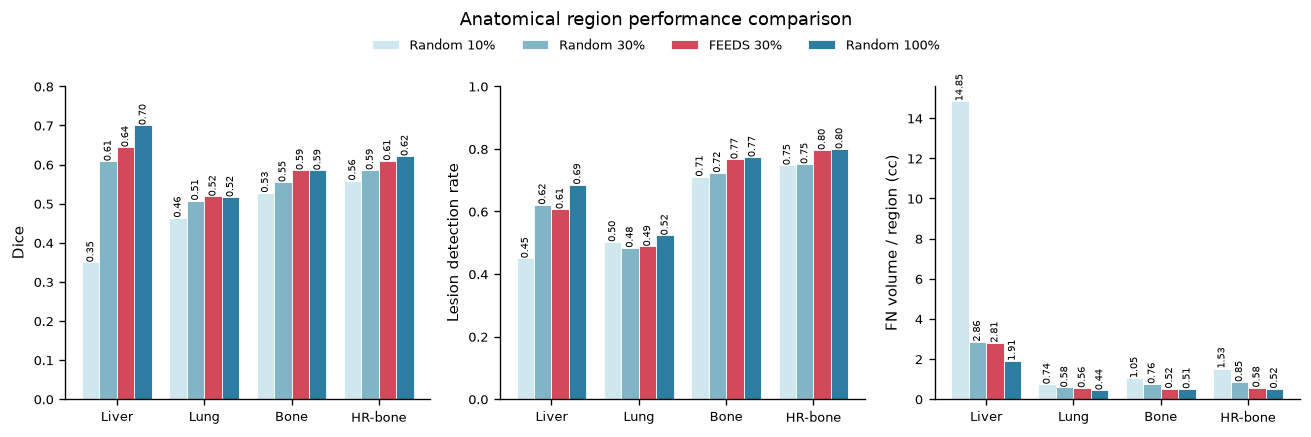

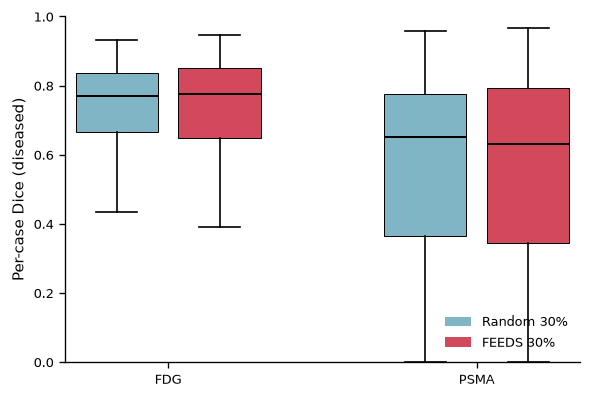

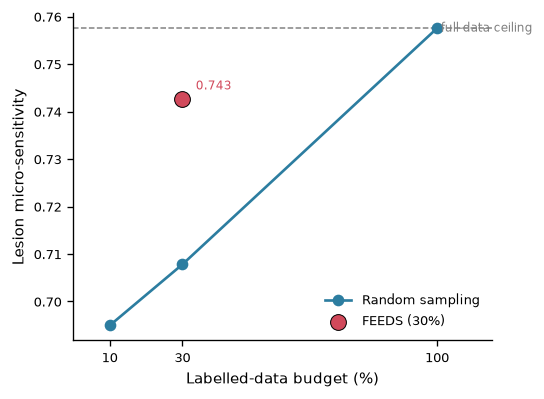

In [19]:
"""
FEEDS paper figures -- matched to the grouped-bar / stratified style of the
inspiration figures (clean, publication-grade, vector + 300 dpi).

Conventions used throughout:
  - Budgets: Random 10/30/100, FEEDS 30. Matched comparison is the 30% pair.
  - Export both a vector PDF (pdf.fonttype 42) and a 300 dpi PNG.
  - Colourblind-safe palette; no chartjunk; thin spines.

Drop these into Section 6 of stat_analysis.ipynb. They read directly from the
CSVs you already have (feeds_organ.csv, random_organ.csv, *_cases.csv, etc.).
"""

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---- global style (run once) -------------------------------------------------
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,      # editable text in vector output
    "font.family": "sans-serif",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.8, "figure.dpi": 120,
})

# colourblind-safe; FEEDS gets the saturated accent, random budgets a ramp
C_FEEDS  = "#D1495B"   # accent red
C_R10    = "#cfe8ef"
C_R30    = "#7fb5c4"
C_R100   = "#2c7da0"

def _save(fig, stem):
    fig.savefig(f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(f"{stem}.png", bbox_inches="tight", dpi=300)
    print(f"saved {stem}.pdf / .png")


# =============================================================================
# FIGURE 1 -- Per-organ grouped bars (Dice + detection + FN volume)
# Mirrors inspiration panel (a): grouped bars, error-free point estimates,
# value labels on top, one panel per metric, organs on the x-axis.
# This is your main "differences across organs" figure.
# =============================================================================
def fig_organ_grouped(feeds_organ="./evaluation_test_results/feeds_organ.csv", random_organ="./evaluation_test_results/random_organ.csv"):
    fo = pd.read_csv(feeds_organ)
    ro = pd.read_csv(random_organ)

    # fold -> budget map
    rmap = {"fold_2": "Random 10%", "fold_6": "Random 30%", "fold_11": "Random 100%"}
    ro = ro[ro["fold"].isin(rmap)].copy()
    ro["arm"] = ro["fold"].map(rmap)
    fo["arm"] = "FEEDS 30%"

    organs = ["liver", "lung", "bone", "hr_bone"]
    organ_lbl = {"liver": "Liver", "lung": "Lung", "bone": "Bone", "hr_bone": "HR-bone"}
    arms = ["Random 10%", "Random 30%", "FEEDS 30%", "Random 100%"]
    colors = {"Random 10%": C_R10, "Random 30%": C_R30,
              "FEEDS 30%": C_FEEDS, "Random 100%": C_R100}

    alld = pd.concat([ro, fo], ignore_index=True)
    alld["det_rate"] = 1 - alld["false_missed_lesion_count"] / alld["gt_lesion_count"]
    alld["FN_cc"] = alld["FN_vol_mean"] / 1000.0   # mm^3 -> cc

    metrics = [("Dice", "Dice", (0, 0.8)),
               ("det_rate", "Lesion detection rate", (0, 1.0)),
               ("FN_cc", "FN volume / region (cc)", None)]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
    x = np.arange(len(organs)); w = 0.2

    for ax, (col, ylab, ylim) in zip(axes, metrics):
        for i, arm in enumerate(arms):
            sub = alld[alld["arm"] == arm].set_index("organ").reindex(organs)
            vals = sub[col].values
            bars = ax.bar(x + (i - 1.5) * w, vals, w, color=colors[arm],
                          edgecolor="white", linewidth=0.5,
                          label=arm if ax is axes[0] else None)
            for b, v in zip(bars, vals):
                if np.isfinite(v):
                    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.2f}",
                            ha="center", va="bottom", fontsize=6, rotation=90)
        ax.set_xticks(x); ax.set_xticklabels([organ_lbl[o] for o in organs])
        ax.set_ylabel(ylab)
        if ylim: ax.set_ylim(*ylim)

    fig.legend(loc="upper center", ncol=4, frameon=False,
               bbox_to_anchor=(0.5, 1.08))
    fig.tight_layout()
    # add a title 
    fig.suptitle("Anatomical region performance comparison", y=1.12, fontsize=11)
    _save(fig, "fig_organ_grouped")
    return fig


# =============================================================================
# FIGURE 2 -- Per-case Dice distributions (box plots, matched 30% pair)
# Mirrors the stratified box plots in the inspiration: FEEDS vs Random at 30%,
# split by tracer. This is where the micro/macro story becomes visible.
# =============================================================================
def fig_dice_boxplots(feeds_cases="./evaluation_test_results/feeds_cases.csv", random_cases="./evaluation_test_results/random_cases.csv"):
    fc = pd.read_csv(feeds_cases)
    rc = pd.read_csv(random_cases)
    rc = rc[rc["fold"] == "fold_6"].copy()   # Random 30%
    fc = fc.copy()
    fc["arm"], rc["arm"] = "FEEDS 30%", "Random 30%"
    d = pd.concat([fc, rc], ignore_index=True)
    d = d[d["diseased"] == True].dropna(subset=["Dice"])

    tracers = ["FDG", "PSMA"]
    fig, ax = plt.subplots(figsize=(5, 3.4))
    positions, data, box_colors, xt = [], [], [], []
    for j, tr in enumerate(tracers):
        for k, (arm, col) in enumerate([("Random 30%", C_R30), ("FEEDS 30%", C_FEEDS)]):
            vals = d[(d["tracer"] == tr) & (d["arm"] == arm)]["Dice"].values
            positions.append(j * 3 + k)
            data.append(vals); box_colors.append(col)
        xt.append(j * 3 + 0.5)

    bp = ax.boxplot(data, positions=positions, widths=0.8, patch_artist=True,
                    showfliers=False, medianprops=dict(color="black", lw=1.2))
    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c); patch.set_edgecolor("black"); patch.set_linewidth(0.6)
    ax.set_xticks(xt); ax.set_xticklabels(tracers)
    ax.set_ylabel("Per-case Dice (diseased)"); ax.set_ylim(0, 1)
    ax.legend(handles=[Patch(facecolor=C_R30, label="Random 30%"),
                       Patch(facecolor=C_FEEDS, label="FEEDS 30%")],
              frameon=False, loc="lower right")
    fig.tight_layout()
    _save(fig, "fig_dice_boxplots")
    return fig


# =============================================================================
# FIGURE 3 -- Data-efficiency curve (sensitivity vs labelling budget)
# The headline AL figure: Random learning curve 10->30->100 with the FEEDS
# point overlaid at 30%, showing it approaches the full-data ceiling.
# Mirrors the clean line+marker ROC/curve panels in the inspiration.
# =============================================================================
def fig_efficiency_curve(feeds_lesion="./evaluation_test_results/feeds_lesion.csv", random_lesion="./evaluation_test_results/random_lesion.csv"):
    fl = pd.read_csv(feeds_lesion); rl = pd.read_csv(random_lesion)
    budget = {"fold_2": 10, "fold_6": 30, "fold_11": 100}
    rl["budget"] = rl["fold"].map(budget)
    rl = rl.sort_values("budget")

    fig, ax = plt.subplots(figsize=(4.6, 3.4))
    ax.plot(rl["budget"], rl["sensitivity_micro"], "-o", color=C_R100,
            label="Random sampling", lw=1.6, ms=6, zorder=2)
    ax.axhline(rl[rl["budget"] == 100]["sensitivity_micro"].iloc[0],
               ls="--", color="gray", lw=0.9, zorder=1)
    ax.text(101, rl[rl["budget"] == 100]["sensitivity_micro"].iloc[0],
            "full-data ceiling", va="center", fontsize=7, color="gray")
    ax.scatter([30], fl["sensitivity_micro"], color=C_FEEDS, s=90, zorder=3,
               edgecolor="black", linewidth=0.6, label="FEEDS (30%)")
    ax.annotate(f"{fl['sensitivity_micro'].iloc[0]:.3f}", (30, fl["sensitivity_micro"].iloc[0]),
                textcoords="offset points", xytext=(8, 6), fontsize=7, color=C_FEEDS)
    ax.set_xlabel("Labelled-data budget (%)")
    ax.set_ylabel("Lesion micro-sensitivity")
    ax.set_xticks([10, 30, 100]); ax.set_xlim(0, 115)
    ax.legend(frameon=False, loc="lower right")
    fig.tight_layout()
    _save(fig, "fig_efficiency_curve")
    return fig


if __name__ == "__main__":
    fig_organ_grouped()
    fig_dice_boxplots()
    fig_efficiency_curve()